# K-Means Clustering: Categorizing Attack Patterns in Unlabeled Phishing URLs

**Nic Recasens** - jr38088@georgiasouthern.edu  
**Nigel Smith** - ns15468@georgiasouthern.edu

Computer Science - Georgia Southern University  
CSCI-7090 Data Science & Machine Learning - Spring 2026

# Overview
This NB applies K-Means clustering to all tuples labeled "other" from the PhishTank dataset; these are URLs that could not be attributed to a specific target. Our goal is to find whether these "others" could be classified by meaningful patterns based on their URL structures alone. "Others" account for ~90% of the Phishtank data points. We utilize the very same lexical features from the SVM notebook (2.0) but apply unsupervised learning instead.

# Import dataset from github

In [1]:
import os

if not os.path.exists('DS_MLProject_ColabIntegration'):
  !git clone https://github.com/ns15468-gasou/DS_ML_Project_ColabIntegration.git
os.chdir('DS_ML_Project_ColabIntegration/Project/notebooks')
print("Working directory", os.getcwd())

fatal: destination path 'DS_ML_Project_ColabIntegration' already exists and is not an empty directory.
Working directory /home/nic/DS_ML_Project_ColabIntegration/Project/notebooks/DS_ML_Project_ColabIntegration/Project/notebooks


# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from urllib.parse import urlparse


# Data Loading

Here we filter to only data points labeled as "other" for Target.

In [3]:
phish = pd.read_csv('../data/processed_input/phishtank_cleaned.csv')

other = phish[phish['target']=='Other'].copy()
print(f"total Phishtank rows: {len(phish)}")
print(f"'Other' rows: {len(other)}")
other.head()

total Phishtank rows: 56045
'Other' rows: 52773


,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target,host,full_length,...,path,path_depth,has_path,tld_ext,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth,domain
0,9358496,https://sgpass-fr033.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03 19:50:49+00:00,yes,2026-03-03 20:12:24+00:00,yes,Other,sgpass-fr033.com,25,...,/,0,0,com,1,1,3,0.120,1,sgpass-fr033.com
1,9358495,https://sgpass-fr033.com/pages/asset.php,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03 19:50:36+00:00,yes,2026-03-03 20:12:24+00:00,yes,Other,sgpass-fr033.com,40,...,/pages/asset.php,2,1,com,2,1,3,0.075,1,sgpass-fr033.com
2,9358485,https://dervi-emprend-ec.webcindario.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03 19:27:05+00:00,yes,2026-03-03 19:32:43+00:00,yes,Other,dervi-emprend-ec.webcindario.com,41,...,/,0,0,com,2,2,0,0.000,2,dervi-emprend-ec.webcindario.com
6,9358476,https://passage-route-mobilites.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03 19:16:14+00:00,yes,2026-03-03 19:22:49+00:00,yes,Other,passage-route-mobilites.com,36,...,/,0,0,com,1,2,0,0.000,1,passage-route-mobilites.com
7,9358475,https://www.passage-route-mobilites.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03 19:16:04+00:00,yes,2026-03-03 19:22:49+00:00,yes,Other,www.passage-route-mobilites.com,40,...,/,0,0,com,2,2,0,0.000,2,passage-route-mobilites.com


# Feature Engineering 
We divide the URLS into 6 features as with NB2.0

In [4]:


phish['host'] = phish['url'].apply(lambda x: urlparse(x).netloc.lower())
phish['full_length'] = phish['url'].str.len()
phish['host_length'] = phish['host'].str.len()
phish['path'] = phish['url'].apply(lambda x: urlparse(x).path)
phish['path_depth'] = phish['path'].apply(lambda p:
p.strip('/').count('/') + 1 if p.strip('/') else 0)
phish['dot_count'] = phish['url'].str.count(r'\.')
phish['hyphen_count'] = phish['url'].str.count('-')
phish['digit_count'] = phish['url'].str.count(r'\d')
phish['digit_ratio'] = phish['digit_count'] / phish['full_length']
phish['subdomain_depth'] = phish['host'].str.count(r'\.')

other = phish[phish['target'] == 'Other'].copy()
print(other.shape)


(52773, 21)


# Scaling
K-Means is distance based, so we want our features to be on the same scale, thus we use StandardScaler

In [5]:
features = ['host_length', 'path_depth', 'dot_count', 'hyphen_count', 'digit_ratio', 'subdomain_depth']

X = other[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (52773, 6)


# Elbow Method

This cell graphically represents how and why we have chosen 4 groups.

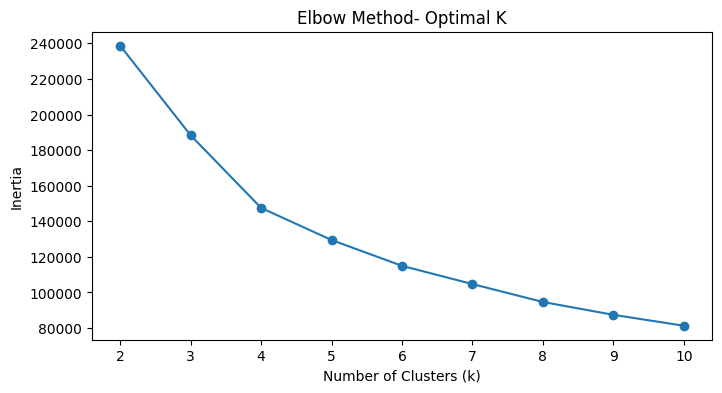

In [6]:
inertia = []
k_range = range(2,11)

for k in k_range:
  km = KMeans(n_clusters=k, random_state=777, n_init=10)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method- Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout
plt.show()


# Note
Seeing as the curve is nearly linear, there does not exist an extremely obvious choice for number of clusters. That said, the most drastic point of change in derivative is at k=4.

In [7]:
km = KMeans(n_clusters=4, random_state=777, n_init=10)
other['cluster'] = km.fit_predict(X_scaled)

print(other['cluster'].value_counts())

cluster
1    21341
3    15517
2     8680
0     7235
Name: count, dtype: int64


In [8]:
cluster_summary = other.groupby('cluster')[features].mean().round(2)
print(cluster_summary)

         host_length  path_depth  dot_count  hyphen_count  digit_ratio  \
cluster                                                                  
0              38.65        0.59       2.82          1.09         0.24   
1              21.29        0.67       2.15          0.44         0.03   
2              15.88        4.51       2.40          2.11         0.10   
3               8.75        1.07       1.07          0.34         0.04   

         subdomain_depth  
cluster                   
0                   2.27  
1                   2.07  
2                   1.99  
3                   1.00  


In [9]:
for c in range(4):
  print(f"\n--- Cluster {c} ---")
  print(other[other['cluster']== c]['url'].sample(5, random_state=777).values)


--- Cluster 0 ---
<StringArray>
['https://pub-7497b4cc97ab46a6a9a492eb1b6a38ec.r2.dev/index.html',
                     'https://eu.jotform.com/app/251023382704347',
                     'https://eu.jotform.com/app/251953383222355',
                         'http://full-language-233771.framer.app',
                        'https://soulful-time-409544.framer.app/']
Length: 5, dtype: str

--- Cluster 1 ---
<StringArray>
['https://sites.google.com/view/oiuiruieor98490krejjkljklejkef/home',
                                      'https://webkkwel.weebly.com/',
                            'https://adminhelpdeskunit1.weebly.com/',
                     'https://reppliesemail80.wixsite.com/my-site-8',
                  'https://id-ionos-de-webmail-system.blogspot.com/']
Length: 5, dtype: str

--- Cluster 2 ---
<StringArray>
[                                                                                                           'https://docs.google.com/presentation/d/e/2PACX-1vS96MJlExf8-vB6

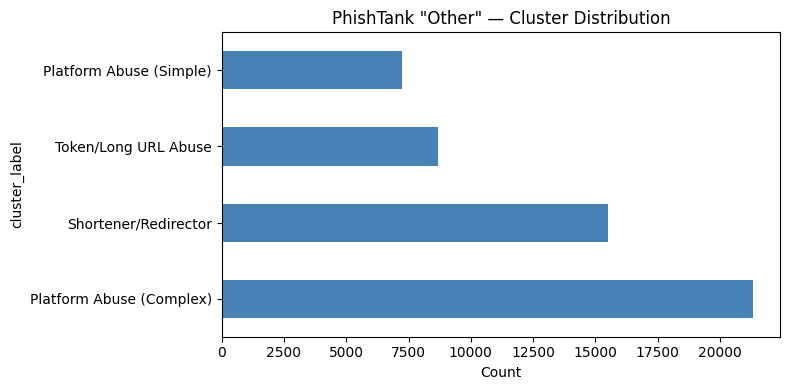

In [10]:
cluster_names = {0: 'Platform Abuse (Simple)',
                 1: 'Platform Abuse (Complex)',
                 2: 'Token/Long URL Abuse', 3: 'Shortener/Redirector'}

other['cluster_label'] = other['cluster'].map(cluster_names)
other['cluster_label'].value_counts().plot(kind='barh', figsize=(8,4),
                                            color='steelblue')
plt.title('PhishTank "Other" — Cluster Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

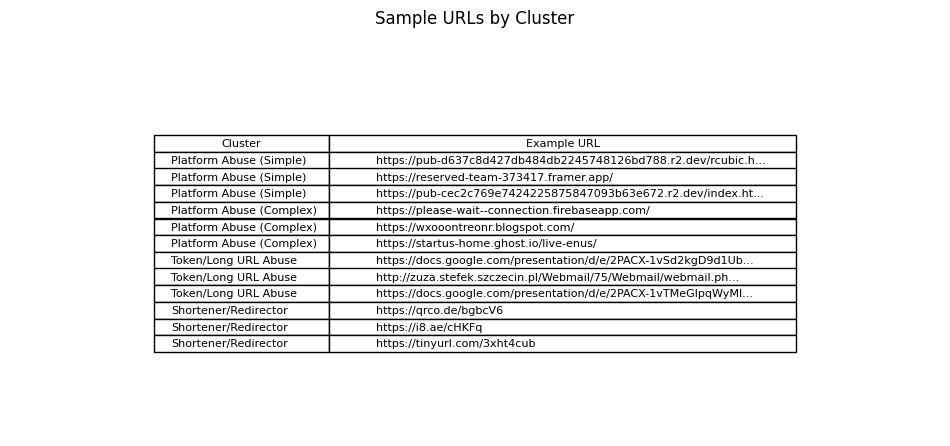

In [11]:
samples = []
for c in range(4):
      label = cluster_names[c]
      urls = other[other['cluster'] == c]['url'].sample(3,
  random_state=42).values
      for url in urls:
          samples.append({'Cluster': label, 'Example URL': url[:60] +
  '...' if len(url) > 60 else url})

sample_df = pd.DataFrame(samples)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
table = ax.table(cellText=sample_df.values, colLabels=sample_df.columns,

                   loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(sample_df.columns))))
plt.title('Sample URLs by Cluster', pad=20)
fig.patch.set_visible(False)
plt.savefig('cluster_samples.png', dpi=150, bbox_inches='tight',
transparent=True)
plt.show()

## References and Data Sources
[1] Gabriela Brezeanu, Alexandru Archip, and Codrut-Georgian Artene. Phish fighter: Self updating machine learning shield against phishing kits based on HTML code analysis. 13:4460-4486.

[2] Bibhu Dash and Meraj Farheen Ansari. An effective cybersecurity awareness training model: First defense of an organizational security strategy. International Research Journal of Engineering and Technology, 9:2395-0056, 04 2022.

[3] Dawn M. Sarno, Maggie W. Harris, and Jeffrey Black. Which phish is captured in the net? understanding phishing susceptibility and individual differences. 37(4):789-803._eprint:onlinelibrary.wiley.com/doi/pdf/10.1002/acp.4075.

[4] Giuseppe Desolda, Francesco Greco, and Luca Vigano. APOLLO: A GPT-based tool to detect phishing emails and generate explanations that warn users. 9(4):EICS003:1-EICS003:33.

[5] Nadjate Saidani, Kamel Adi, and Mohand Saïd Allili. A semantic-based classification approach for an enhanced spam detection. Computers & Security, 94, 2020-07.

[6] Sonowal and Gunikhan. Detecting phishing sms based on multiple correlation algorithms. SN Computer Science, 1, 11 2020.

[7] Panpan Zhang, Jing Ya, Tingwen Liu, Quangang Li, Jinqiao Shi, and Zhaojun Gu. imcircle: Automatic mining of indicators of compromise from the web. In 2019 IEEE  symposium on Computers and Communications (ISCC), 2019.

[8] Rasha Zieni, Luisa Massari, and Maria Carla Calzarossa. Phishing or not phishing? a survey on the detection of phishing websites. 11:18499-18519.

[9] Chugani, Vinod. “What Is Cosine Distance?” Datacamp.com, DataCamp, 28 July 2024, datacamp.com/tutorial/cosine-distance.

[10] Cisco Systems, Inc. PhishTank: Join the fight against phishing. phishtank.com, 2026.

[11] Victor Le Pochat, Tom Van Goethem, Samaneh Tajalizadehkhoob, Maciej Korczy´nski, and Wouter Joosen. Tranco: A Research-Oriented Top Sites Ranking Hardened Against Manipulation. In Proceedings of the 26th Annual Network and Distributed System Security Symposium (NDSS), 2019.